# Logistic Regression from Scratch

In this notebook, I build Logistic Regression step by step using NumPy. I also train it using Gradient Descent. I am sharing my work here. I hope it helps other students who are learning the same thing.

Logistic Regression is used for classification problems. It predicts a category (like yes or no, spam or not spam) instead of a regular number. 

First, we will look at the basic idea and the math behind it. 
Then, we will code it from scratch. Finally, we will compare our code to scikit-learn to make sure it works right.

## What is Logistic Regression?

Linear Regression is good when we want to predict a number, like a price or a score. But what if we want to predict something like "yes or no"? For example: will a student get placed or not, based on their CGPA?

If we try to use a normal straight line here, it causes a problem. A straight line can go below 0 or above 1, but "placed or not" only makes sense as 0 or 1. 
A value like -0.3 or 1.7 doesn't mean anything in this case.

This is where Logistic Regression helps. Instead of drawing a straight line, it draws an S-shaped curve. This curve always stays between 0 and 1, no matter how big or small the input is. We can think of this output as a **probability** - for example, "there is an 80% chance this student will get placed, based on their CGPA."

Once we have this probability, we need to turn it into a final answer (placed or not placed). To do this, we set a simple rule: if the probability is 0.5 or higher, we predict "placed" (1). If it's lower than 0.5, we predict "not placed" (0). This 0.5 point is called the **threshold**.

## The Math Behind the Curve

So how does this S-shaped curve actually work? It comes from a function
called the **Sigmoid function**:

$$\sigma(z) = \frac{1}{1+e^{-z}}$$

Here, `z` is just our normal linear equation from before:

$$z = wx + b$$

So the full model becomes:

$$\hat{y} = \sigma(wx+b) = \frac{1}{1+e^{-(wx+b)}}$$

Let's understand why this formula always gives a value between 0 and 1.

If `z` is a big positive number (say 10), then $e^{-z}$ becomes a very
tiny number close to 0. So the formula becomes roughly $\frac{1}{1+0} = 1$.

If `z` is a big negative number (say -10), then $e^{-z}$ becomes a huge
number. So the formula becomes roughly $\frac{1}{\text{huge number}}$,
which is basically 0.

And if `z = 0`, we get $\frac{1}{1+1} = 0.5$, right in the middle.

This is why no matter how big or small `z` gets, the output always stays
squeezed between 0 and 1 — which makes it perfect to use as a probability.

## Why Can't We Use MSE Here?

In Linear Regression, we used Mean Squared Error (MSE) to measure how
wrong our predictions were. But for Logistic Regression, MSE doesn't work
well. When we combine MSE with the sigmoid function, the cost function
ends up with a lot of bumps and dips (it becomes non-convex), so gradient
descent can easily get stuck in the wrong place instead of finding the
best answer.

So instead, we use something called **Log Loss** (also called Binary
Cross-Entropy):

$$J(w,b) = -\frac{1}{n}\sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \right]$$

This looks scary at first, but it's easier than it seems. Let's break it
into two cases.

**Case 1: When the actual answer is 1 (placed)**

The second part of the formula becomes 0 (because $1 - 1 = 0$), so we're
left with just:

$$-\log(\hat{y}_i)$$

If our model predicted something close to 1 (a good guess), $\log(\hat{y}_i)$
is close to 0, so the cost is very small. But if our model predicted
something close to 0 (a bad guess), $\log(\hat{y}_i)$ becomes a large
negative number, and after the minus sign, the cost becomes very large.
So a confident wrong guess gets punished heavily.

**Case 2: When the actual answer is 0 (not placed)**

Now the first part becomes 0, and we're left with:

$$-\log(1-\hat{y}_i)$$

The same idea applies here, just in the opposite direction — if the model
predicted close to 0 (correct), the cost is small. If it predicted close
to 1 (wrong), the cost is large.

So overall, this cost function punishes the model more when it's
confidently wrong, and rewards it when it's confidently right.

## Math: How Does the Model Actually Learn?

Okay, so now we have our cost function (Log Loss) from before. But just
knowing the cost isn't enough — we need to know **how to change `w` and
`b`** to make that cost go down.

To do that, we need to find something called a "gradient" — basically,
it tells us in which direction we should change `w` and `b` to reduce
the cost.

**Why is this a bit tricky here?**

In Linear Regression, `w` directly affected our prediction. But here,
there's an extra step in between. Let's see the full path:

Basically, `w` doesn't change the error directly. It changes `z`, which changes our prediction `ŷ`, which *then* gives us the cost `J`. Since it's a chain reaction, we have to use the **chain rule** from calculus. You just multiply all the steps together to see the total effect:

$$\frac{\partial J}{\partial w} = \frac{\partial J}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w}$$

I'm going to skip writing out all the heavy algebra because it gets pretty messy. But one cool trick to know is that the derivative of the sigmoid function is actually super simple:

$$\sigma'(z) = \hat{y}(1-\hat{y})$$

If you plug all the math in, a bunch of ugly stuff magically cancels out. We end up with these really clean final formulas:

$$\frac{\partial J}{\partial w} = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i) \cdot x_i$$

$$\frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n} (\hat{y}_i - y_i)$$

The crazy part to me is that these look exactly like the formulas we used for Linear Regression! The only real difference is that our $\hat{y}_i$ here is calculated using the sigmoid curve instead of just a straight line.

**Updating our weights**

Now that we have the gradients, we just tweak `w` and `b` by taking tiny steps, exactly like we did before:

$$w := w - \alpha \cdot \frac{\partial J}{\partial w}$$

$$b := b - \alpha \cdot \frac{\partial J}{\partial b}$$

Here, $\alpha$ is our learning rate (which tells the model how big of a step to take). We just loop this over and over until the cost drops as low as it can go and stops changing much.

In [ ]:
import numpy as np

np.random.seed(42)
n_samples = 100

cgpa = 5 + 5*np.random.rand(n_samples,1)

z = cgpa - 7.5
probability = 1/(1+np.exp(-z))

random_values = np.random.rand(n_samples,1)
placed = (probability > random_values).astype(int)

print(cgpa[:5])
print(probability[:5])
print(placed[:5])


[[6.87270059]
 [9.75357153]
 [8.65996971]
 [7.99329242]
 [5.7800932 ]]
[[0.34812314]
 [0.90495816]
 [0.76132721]
 [0.62088174]
 [0.15188317]]
[[1]
 [1]
 [1]
 [1]
 [0]]


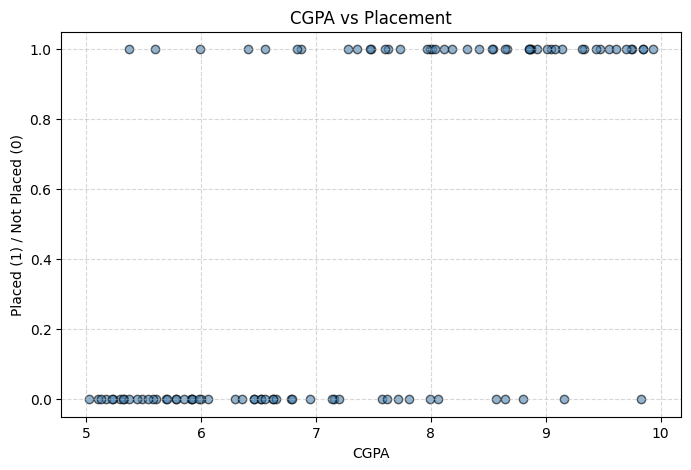

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(cgpa, placed, color="steelblue", alpha=0.6, edgecolor="k")
plt.xlabel("CGPA")
plt.ylabel("Placed (1) / Not Placed (0)")
plt.title("CGPA vs Placement")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [3]:
import numpy as np
from ml_from_scratch.base_model import BaseModel

class LogisticRegression(BaseModel):

    def __init__(self, learning_rate = 0.1, n_iterations = 1000):
        super().__init__()
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weight = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self, z):
        return 1/(1+np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weight = np.zeros((n_features,1))
        self.bias = 0.0
        y = y.reshape(-1,1)

        for _ in range(self.n_iterations):
            z = np.dot(X, self.weight) + self.bias
            predictions = self.sigmoid(z)

            error = predictions - y

            cost = -np.mean(y * np.log(predictions) + (1-y) * np.log(1-predictions)) # log loss
            self.cost_history.append(cost)

            weight_gradient = (1/n_samples) * np.dot(X.T, error)
            bias_gradient = (1/n_samples) * np.sum(error)

            self.weight -= self.learning_rate * weight_gradient
            self.bias -= self.learning_rate * bias_gradient

        self.is_fitted = True
        return self

    def predict_probability(self, X):
        self._check_is_fitted()
        z = np.dot(X, self.weight) + self.bias
        return self.sigmoid(z)

    def predict(self, X):
        probabilities = self.predict_probability(X)
        return (probabilities >= 0.5).astype(int)
       
 

In [4]:
model = LogisticRegression(learning_rate=0.1, n_iterations=1000)
model.fit(cgpa, placed)

print("Learned weight:", model.weight[0][0])
print("Learned bias:", model.bias)

Learned weight: 0.5399602619367988
Learned bias: -3.9855781231337386


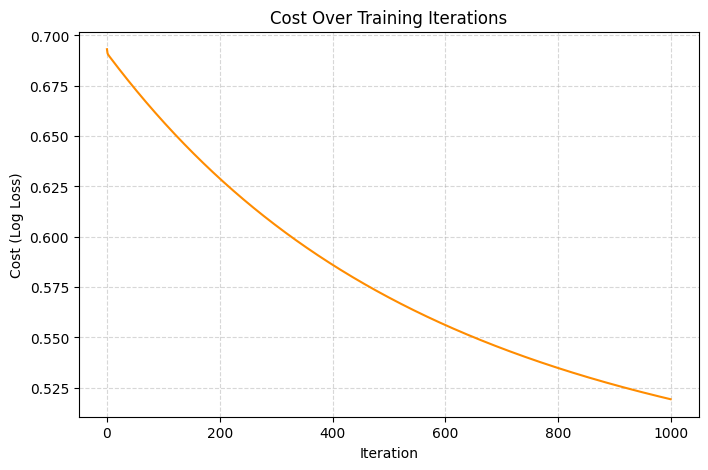

In [5]:
plt.figure(figsize=(8,5))
plt.plot(range(len(model.cost_history)), model.cost_history, color="darkorange")
plt.xlabel("Iteration")
plt.ylabel("Cost (Log Loss)")
plt.title("Cost Over Training Iterations")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [8]:
model = LogisticRegression(learning_rate=0.1, n_iterations=5000)
model.fit(cgpa, placed)

print("Learned weight:",model.weight[0][0])
print("Learned Bias:",model.bias)

Learned weight: 1.0485796553798952
Learned Bias: -7.851475654401825


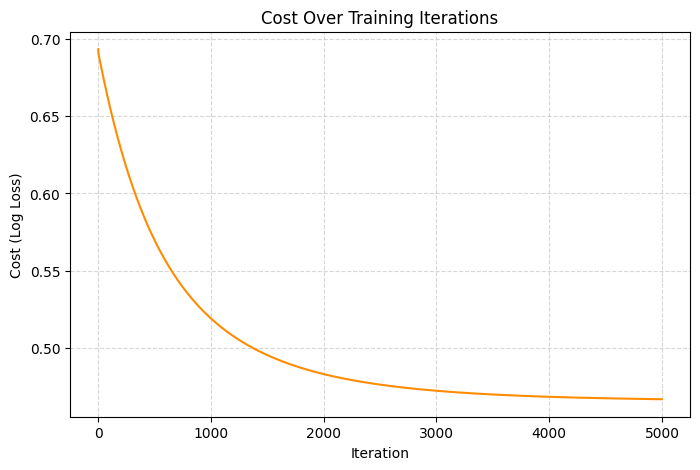

In [9]:
plt.figure(figsize=(8,5))
plt.plot(range(len(model.cost_history)), model.cost_history, color="darkorange")
plt.xlabel("Iteration")
plt.ylabel("Cost (Log Loss)")
plt.title("Cost Over Training Iterations")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

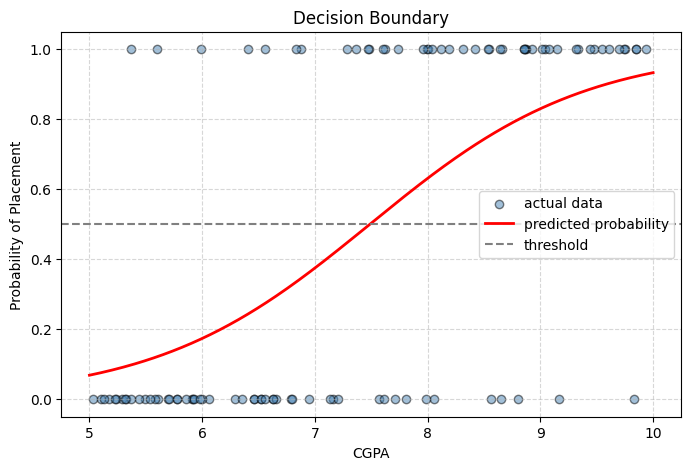

In [11]:
cgpa_range = np.linspace(5, 10, 300).reshape(-1,1)
probabilities = model.predict_probability(cgpa_range)

plt.figure(figsize=(8,5))
plt.scatter(cgpa, placed, color="steelblue", alpha=0.5, edgecolor="k", label="actual data")
plt.plot(cgpa_range, probabilities, color="red", linewidth=2, label="predicted probability")
plt.axhline(0.5, color="gray", linestyle="--", label="threshold")
plt.xlabel("CGPA")
plt.ylabel("Probability of Placement")
plt.title("Decision Boundary")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## How Do We Check If This Model Is Good?

For Linear Regression, we used MSE and R² to check how good our model
was. But those don't really make sense here, since we are not predicting
a number anymore — we are predicting a category (placed or not placed).

So for classification problems like this one, we use a different set of
metrics.

**Confusion Matrix**
This just shows us where the model got things right and where it got
things wrong. There are four cases:
- Predicted placed, and the student was actually placed (correct)
- Predicted not placed, and the student was actually not placed (correct)
- Predicted placed, but the student wasn't actually placed (wrong)
- Predicted not placed, but the student was actually placed (wrong)

**Accuracy**
This is just the percentage of predictions the model got right overall.
It's simple, but it can be misleading if the data is imbalanced (like if
95% of students got placed, a model that always says "placed" would still
look 95% accurate, even though it's not really learning anything).

**Precision**
Out of all the times the model predicted "placed", how many were actually
placed? This matters when a false "placed" prediction is costly.

**Recall**
Out of all the students who were actually placed, how many did the model
correctly catch? This matters more when missing an actual positive case
is costly.

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

predictions = model.predict(cgpa)

accuracy = accuracy_score(placed, predictions)
conf_matrix = confusion_matrix(placed, predictions)
precision = precision_score(placed, predictions)
recall = recall_score(placed, predictions)

print("Accuracy score:",accuracy)
print("confusion matrix:",conf_matrix)
print("Precision score:",precision)
print("Recall score",recall)

Accuracy score: 0.78
confusion matrix: [[42 11]
 [11 36]]
Precision score: 0.7659574468085106
Recall score 0.7659574468085106


In [13]:
from sklearn.linear_model import LogisticRegression as SklearnLogisticRegression

sklearn_model = SklearnLogisticRegression()
sklearn_model.fit(cgpa, placed.ravel())

sklearn_predictions = sklearn_model.predict(cgpa)

sklearn_accuracy = accuracy_score(placed, sklearn_predictions)
sklearn_precision = precision_score(placed, sklearn_predictions)
sklearn_recall = recall_score(placed, sklearn_predictions)

print(sklearn_accuracy)
print(sklearn_precision)
print(sklearn_recall)

0.78
0.7659574468085106
0.7659574468085106


## Conclusion

In this notebook, I built Logistic Regression from scratch using just
NumPy. I learned how it's different from Linear Regression instead of
predicting a number, it predicts a probability using the sigmoid
function, and then turns that into a category (placed or not placed)
using a threshold.

I also learned why we can't use MSE here, and had to use Log Loss
instead. Deriving the gradient using the chain rule was a bit confusing
at first, but the final formula turned out to be almost the same as
Linear Regression, which was a nice surprise.

For evaluation, I used accuracy, precision, and recall instead of
MSE/R², since this is a classification problem. My model's results
matched scikit-learn's exactly, which confirms the implementation is
correct.

One thing I noticed is that the model never gets 100% accuracy on this
data, and that's expected, since I added some randomness while
generating the labels, a few students near the decision boundary will
always be hard to classify correctly.